In [1]:
include("./dmrg_helper_functions.jl")

Main.DMRGHelperFunctions

In [2]:
using Pkg
Pkg.activate("..")
using ITensors
using ITensorMPS
using .DMRGHelperFunctions


  Activating project at `~/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks`


In [3]:
nn = 5
system = siteinds("S=1/2", nn);

In [4]:
psi0 = random_mps(ComplexF64, system, linkdims=64);

In [5]:
opsum = OpSum()
for j in 1:nn-1
    opsum += -1.0 , "S-", j, "S+", j+1
    opsum += -1.0 , "S+", j, "S-", j+1
end
ham = MPO(opsum, system)

5-element MPO:
 ((dim=4|id=925|"Link,l=1"), (dim=2|id=921|"S=1/2,Site,n=1")', (dim=2|id=921|"S=1/2,Site,n=1"))
 ((dim=4|id=925|"Link,l=1"), (dim=4|id=508|"Link,l=2"), (dim=2|id=987|"S=1/2,Site,n=2")', (dim=2|id=987|"S=1/2,Site,n=2"))
 ((dim=4|id=508|"Link,l=2"), (dim=4|id=382|"Link,l=3"), (dim=2|id=143|"S=1/2,Site,n=3")', (dim=2|id=143|"S=1/2,Site,n=3"))
 ((dim=4|id=382|"Link,l=3"), (dim=4|id=797|"Link,l=4"), (dim=2|id=18|"S=1/2,Site,n=4")', (dim=2|id=18|"S=1/2,Site,n=4"))
 ((dim=4|id=797|"Link,l=4"), (dim=2|id=870|"S=1/2,Site,n=5")', (dim=2|id=870|"S=1/2,Site,n=5"))

In [6]:
myProjMPO = ProjMPO(ham)
myProjMPO.nsite=1
position!(myProjMPO,psi0, 1)
@show myProjMPO



myProjMPO = ProjMPO(0, 2, 1, MPO(5), ITensor[#undef, ITensor ord=3
Dim 1: (dim=16|id=945|"Link,l=1")
Dim 2: (dim=4|id=925|"Link,l=1")
Dim 3: (dim=16|id=945|"Link,l=1")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 16×4×16
[:, :, 1] =
      0.9999999999999996 + 2.2296758316349212e-17im  …    0.08957788678046945 - 8.889533106095528e-17im
 -2.4032906507132577e-16 + 4.4787554933374323e-17im       -0.4591131296247224 - 0.17644226051714226im
   -9.68533004222008e-17 - 1.0838480166734412e-16im        0.4932134210254834 - 0.03958424169445545im
  1.1777667209307818e-17 + 1.686881669330007e-16im        0.16264693060735605 - 0.12072688832042698im
  -2.824478928857504e-17 + 1.6533893010831761e-16im      -0.08210384494480939 + 0.08810855262884508im
  -5.505496014195804e-17 - 2.7204277760116965e-17im  …   -0.19849721816128466 + 0.26598293420801317im
   5.934634639125436e-17 + 1.1743803463219705e-17im      -0.09675203410163748 + 0.1771840090955042im
  1.1310989675611486e-16 - 1.1308497427808676e-

ProjMPO(0, 2, 1, MPO(5), ITensor[#undef, ITensor ord=3
Dim 1: (dim=16|id=945|"Link,l=1")
Dim 2: (dim=4|id=925|"Link,l=1")
Dim 3: (dim=16|id=945|"Link,l=1")'
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 16×4×16
[:, :, 1] =
      0.9999999999999996 + 2.2296758316349212e-17im  …    0.08957788678046945 - 8.889533106095528e-17im
 -2.4032906507132577e-16 + 4.4787554933374323e-17im       -0.4591131296247224 - 0.17644226051714226im
   -9.68533004222008e-17 - 1.0838480166734412e-16im        0.4932134210254834 - 0.03958424169445545im
  1.1777667209307818e-17 + 1.686881669330007e-16im        0.16264693060735605 - 0.12072688832042698im
  -2.824478928857504e-17 + 1.6533893010831761e-16im      -0.08210384494480939 + 0.08810855262884508im
  -5.505496014195804e-17 - 2.7204277760116965e-17im  …   -0.19849721816128466 + 0.26598293420801317im
   5.934634639125436e-17 + 1.1743803463219705e-17im      -0.09675203410163748 + 0.1771840090955042im
  1.1310989675611486e-16 - 1.1308497427808676e-16im       0

In [7]:
using KrylovKit: eigsolve
using Plots

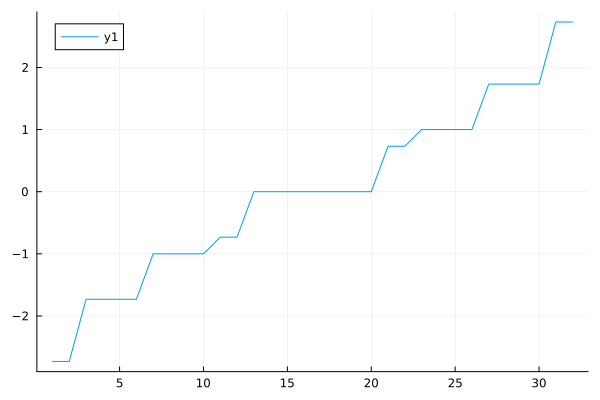

In [8]:
myOp = myProjMPO.LR[2]*ham[1]
l1 = inds(myOp,tags="Link",plev=0)[1]
s1 = inds(myOp,tags="Site",plev=0)[1]
l1prime = inds(myOp,tags="Link",plev=1)[1]
s1prime = inds(myOp,tags="Site",plev=1)[1]
c1 = combiner(l1,s1)
c1prime = combiner(l1prime,s1prime)
myOp = c1prime*myOp*c1
vals,vecs = eigen(matrix(myOp));
plot(real(vals))

Davidson is completely off!!!!!

In [9]:
vals,vecs,info = eigsolve(myProjMPO,psi0[1], 1,:SR;ishermitian=true, tol=1e-14, maxiter=100);


In [10]:
vals


28-element Vector{Float64}:
 -2.7320508075688767
 -2.7320508075688728
 -1.7320508075688814
 -1.732050807568879
 -1.7320508075688745
 -1.7320508075688712
 -1.0000000000000004
 -0.9999999999999993
 -0.9999999999999957
 -0.9999999999999952
  ⋮
  0.9999999999999989
  1.0
  1.0000000000000013
  1.7320508075688754
  1.7320508075688759
  1.7320508075688763
  1.732050807568877
  2.732050807568876
  2.7320508075688767

In [12]:
 apply_H = v -> begin
            Hv = v * ham[1]
            Hv = Hv * myProjMPO.LR[2]
            noprime(Hv)
        end


        E, psi0[1] = davidson(apply_H, psi0[1]; maxiter=50, tol=1e-14)

(-2.7320508075688767, ITensor ord=2
Dim 1: (dim=2|id=921|"S=1/2,Site,n=1")
Dim 2: (dim=16|id=945|"Link,l=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×16
 -0.12920691438146428 - 0.007321281292943902im  …   0.10498233657419925 - 0.024132453189437172im
  0.09071900325392473 - 0.17434908080633657im      -0.11582414701045607 + 0.036088030671581624im
)